# 데이터 분석 제 1차 프로젝트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('./pohang_train_2018_2023.csv')
df

,일시,지점,지점명,강수량(mm),강수량 QC플래그,source_file,date,daily_rain,water_level,heavy_rain
0,2018-01-01 00:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
1,2018-01-01 01:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
2,2018-01-01 02:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
3,2018-01-01 03:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
4,2018-01-01 04:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
...,...,...,...,...,...,...,...,...,...,...
52579,2023-12-31 19:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0
52580,2023-12-31 20:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0
52581,2023-12-31 21:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0
52582,2023-12-31 22:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0


In [3]:
# 한글 인덱스 영어 인덱스로 수정
df1 = df.rename(columns={
    '일시' : 'datetime',
    '강수량(mm)' : 'hourly_rain'
})
df1

,datetime,지점,지점명,hourly_rain,강수량 QC플래그,source_file,date,daily_rain,water_level,heavy_rain
0,2018-01-01 00:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
1,2018-01-01 01:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
2,2018-01-01 02:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
3,2018-01-01 03:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
4,2018-01-01 04:00:00,138,포항,0.0,NaN,NaN,2018-01-01,0.0,0.97,0
...,...,...,...,...,...,...,...,...,...,...
52579,2023-12-31 19:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0
52580,2023-12-31 20:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0
52581,2023-12-31 21:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0
52582,2023-12-31 22:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0


In [4]:
# 'datetime'타입으로 자료 타입 변환
df1['datetime'] = pd.to_datetime(df1['datetime'])

# 'datetime' 자료 연/월/일/시로 구분하여 새로운 column 만들기
df1['year'] = df1['datetime'].dt.year
df1['month'] = df1['datetime'].dt.month
df1['day'] = df1['datetime'].dt.day
df1['hour'] = df1['datetime'].dt.hour

# 3시간 누적 데이터 생성
df1['rain_3h'] = df1['hourly_rain'].rolling(3).sum()
# 6시간 누적 데이터 생성
df1['rain_6h'] = df1['hourly_rain'].rolling(6).sum()
# 9시간 누적 데이터 생성
df1['rain_9h'] = df1['hourly_rain'].rolling(9).sum()
# 12시간 누적 데이터 생성
df1['rain_12h'] = df1['hourly_rain'].rolling(12).sum()

# Nan 자료 0으로 채우기
df1 = df1.fillna(0)

df1

,datetime,지점,지점명,hourly_rain,강수량 QC플래그,source_file,date,daily_rain,water_level,heavy_rain,year,month,day,hour,rain_3h,rain_6h,rain_9h,rain_12h
0,2018-01-01 00:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,0,0.0,0.0,0.0,0.0
1,2018-01-01 01:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,1,0.0,0.0,0.0,0.0
2,2018-01-01 02:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,2,0.0,0.0,0.0,0.0
3,2018-01-01 03:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,3,0.0,0.0,0.0,0.0
4,2018-01-01 04:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,4,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52579,2023-12-31 19:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,19,0.0,0.0,0.0,0.0
52580,2023-12-31 20:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,20,0.0,0.0,0.0,0.0
52581,2023-12-31 21:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,21,0.0,0.0,0.0,0.0
52582,2023-12-31 22:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,22,0.0,0.0,0.0,0.0


In [5]:
# 3시간 누적 강수량과 12시간 누적 강수량을 기준으로 호우주의보 발령 가능성 예측
x = df1['rain_3h'] >= 60
y = df1['rain_12h'] >= 110
df1['heavy_risk'] = (x | y).astype(int)
df1

,datetime,지점,지점명,hourly_rain,강수량 QC플래그,source_file,date,daily_rain,water_level,heavy_rain,year,month,day,hour,rain_3h,rain_6h,rain_9h,rain_12h,heavy_risk
0,2018-01-01 00:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,0,0.0,0.0,0.0,0.0,0
1,2018-01-01 01:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,1,0.0,0.0,0.0,0.0,0
2,2018-01-01 02:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,2,0.0,0.0,0.0,0.0,0
3,2018-01-01 03:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,3,0.0,0.0,0.0,0.0,0
4,2018-01-01 04:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,4,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52579,2023-12-31 19:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,19,0.0,0.0,0.0,0.0,0
52580,2023-12-31 20:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,20,0.0,0.0,0.0,0.0,0
52581,2023-12-31 21:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,21,0.0,0.0,0.0,0.0,0
52582,2023-12-31 22:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,22,0.0,0.0,0.0,0.0,0


In [6]:
# 'month' 데이터로 계절 column 새로 만들기
def get_season(month):
    # 0 : 봄
    if month in [3,4,5]:
        return 0
    # 1 : 여름
    elif month in [6,7,8]:
        return 1
    # 2 : 가을
    elif month in [9,10,11]:
        return 2
    # 3 : 겨울
    else:
        return 3

df1['season'] = df1['month'].apply(get_season)
df1

,datetime,지점,지점명,hourly_rain,강수량 QC플래그,source_file,date,daily_rain,water_level,heavy_rain,year,month,day,hour,rain_3h,rain_6h,rain_9h,rain_12h,heavy_risk,season
0,2018-01-01 00:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,0,0.0,0.0,0.0,0.0,0,3
1,2018-01-01 01:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,1,0.0,0.0,0.0,0.0,0,3
2,2018-01-01 02:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,2,0.0,0.0,0.0,0.0,0,3
3,2018-01-01 03:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,3,0.0,0.0,0.0,0.0,0,3
4,2018-01-01 04:00:00,138,포항,0.0,0.0,0,2018-01-01,0.0,0.97,0,2018,1,1,4,0.0,0.0,0.0,0.0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52579,2023-12-31 19:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,19,0.0,0.0,0.0,0.0,0,3
52580,2023-12-31 20:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,20,0.0,0.0,0.0,0.0,0,3
52581,2023-12-31 21:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,21,0.0,0.0,0.0,0.0,0,3
52582,2023-12-31 22:00:00,138,포항,0.0,9.0,포항_시간강수량_2023.csv,2023-12-31,0.0,1.16,0,2023,12,31,22,0.0,0.0,0.0,0.0,0,3


In [7]:
# 필요한 데이터 column들만 모으기
df2 = df1[['year', 'month', 'day', 'hour', 'season',
           'hourly_rain','rain_3h', 'rain_6h', 'rain_9h', 'rain_12h',
           'daily_rain', 'water_level', 'heavy_risk', 'heavy_rain']]
df2

,year,month,day,hour,season,hourly_rain,rain_3h,rain_6h,rain_9h,rain_12h,daily_rain,water_level,heavy_risk,heavy_rain
0,2018,1,1,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.97,0,0
1,2018,1,1,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.97,0,0
2,2018,1,1,2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.97,0,0
3,2018,1,1,3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.97,0,0
4,2018,1,1,4,3,0.0,0.0,0.0,0.0,0.0,0.0,0.97,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52579,2023,12,31,19,3,0.0,0.0,0.0,0.0,0.0,0.0,1.16,0,0
52580,2023,12,31,20,3,0.0,0.0,0.0,0.0,0.0,0.0,1.16,0,0
52581,2023,12,31,21,3,0.0,0.0,0.0,0.0,0.0,0.0,1.16,0,0
52582,2023,12,31,22,3,0.0,0.0,0.0,0.0,0.0,0.0,1.16,0,0


In [8]:
data_unique = df2[['year', 'month', 'day', 'hourly_rain',
                   'daily_rain', 'heavy_rain']]
data_unique1 = data_unique.drop_duplicates(subset=['year', 'month', 'day'], keep='first').reset_index(drop=True)
data_unique1

,year,month,day,hourly_rain,daily_rain,heavy_rain
0,2018,1,1,0.0,0.0,0
1,2018,1,2,0.0,0.0,0
2,2018,1,3,0.0,0.0,0
3,2018,1,4,0.0,0.0,0
4,2018,1,5,0.0,0.0,0
...,...,...,...,...,...,...
2186,2023,12,27,0.0,0.0,0
2187,2023,12,28,0.0,0.0,0
2188,2023,12,29,0.0,0.0,0
2189,2023,12,30,0.0,0.5,0


In [9]:
monthly_heavy = data_unique1[data_unique1['heavy_rain'] == 1] \
                .groupby(['year', 'month']) \
                .size() \
                .reset_index(name='count')
monthly_heavy

,year,month,count
0,2018,6,1
1,2018,7,1
2,2018,8,2
3,2018,10,2
4,2019,6,1
5,2019,7,2
6,2019,8,1
7,2019,9,1
8,2019,10,1
9,2020,6,1


In [10]:
years = sorted(monthly_heavy['year'].unique())
years

[np.int32(2018),
 np.int32(2019),
 np.int32(2020),
 np.int32(2021),
 np.int32(2022),
 np.int32(2023)]

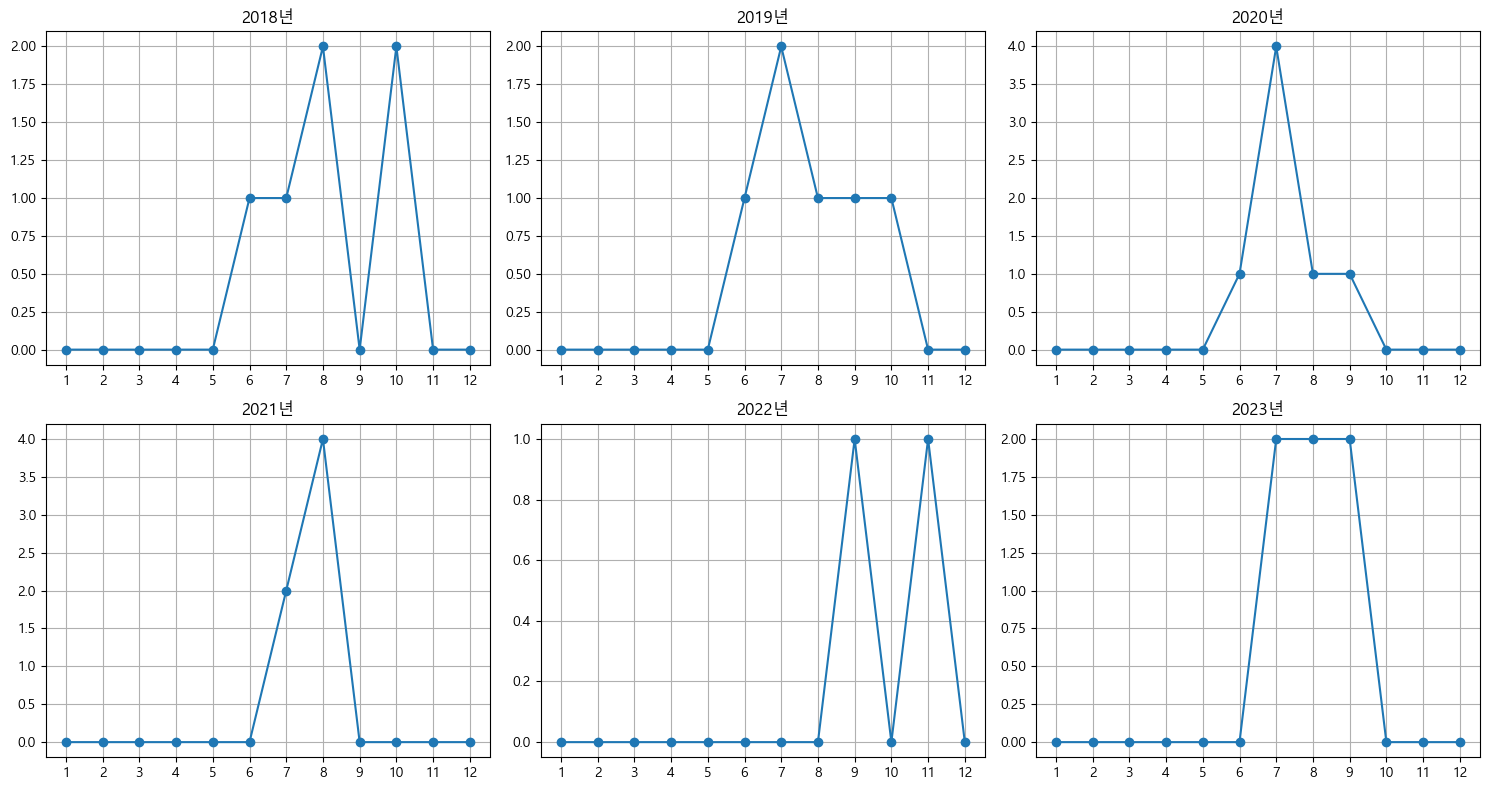

In [11]:
all_months = pd.DataFrame({'month': range(1, 13)})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    temp = monthly_heavy[monthly_heavy['year'] == year]
    
    # 월 채우기 (없는 월 = 0)
    temp = all_months.merge(temp, on='month', how='left').fillna(0)
    
    ax.plot(temp['month'], temp['count'], marker='o')
    ax.set_title(f'{year}년')
    ax.set_xticks(range(1, 13))
    ax.grid()

plt.tight_layout()
plt.show()

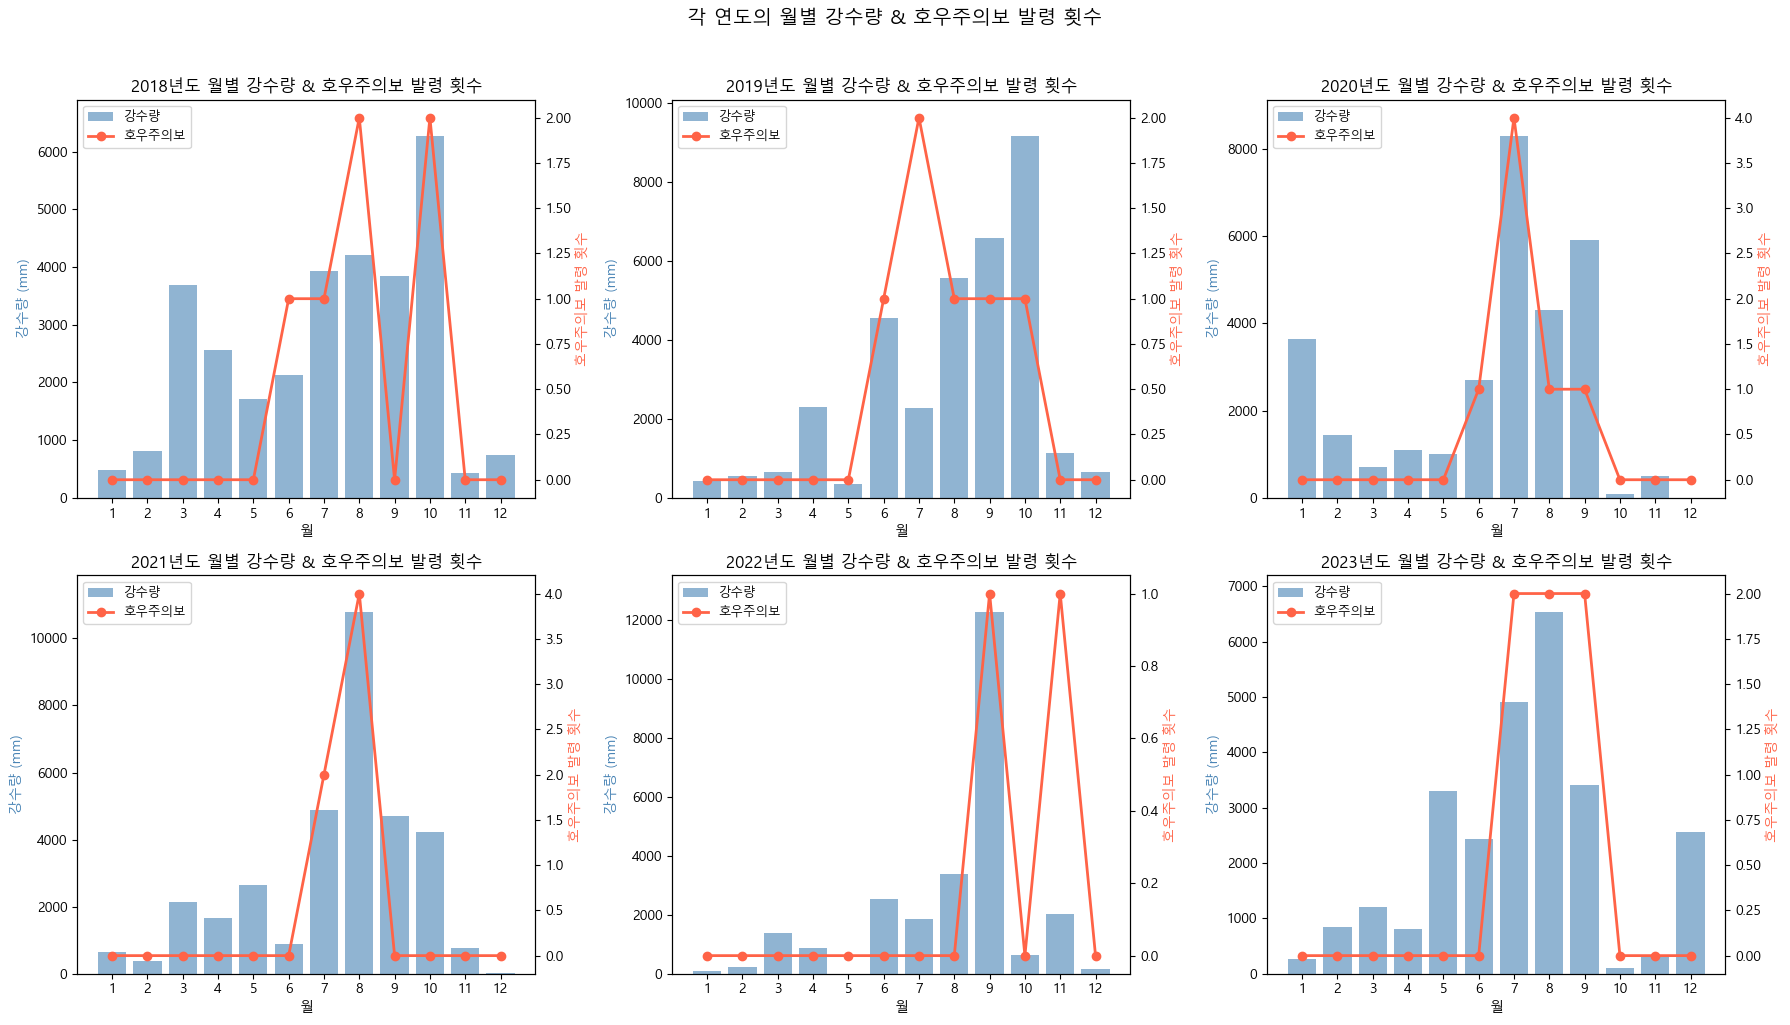

In [12]:
years = sorted(df2['year'].unique())
all_months = pd.DataFrame({'month': range(1, 13)})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, year in enumerate(years):
    ax1 = axes[i]
    ax2 = ax1.twinx()  # 이중 y축

    # 막대그래프 — 월별 총 강수량
    monthly_rain = (
        df2[df2['year'] == year]
        .groupby('month')['daily_rain']
        .sum()
        .reset_index(name='rain_sum')
    )
    monthly_rain = all_months.merge(monthly_rain, on='month', how='left').fillna(0)
    ax1.bar(monthly_rain['month'], monthly_rain['rain_sum'],
            color='steelblue', alpha=0.6, label='강수량')

    # 꺾은선 그래프 — 월별 호우주의보 발령 횟수
    monthly_risk = (
        data_unique1[(data_unique1['year'] == year) & (data_unique1['heavy_rain'] == 1)]
        .groupby('month')['heavy_rain']
        .count()
        .reset_index(name='count')
    )
    monthly_risk = all_months.merge(monthly_risk, on='month', how='left').fillna(0)
    ax2.plot(monthly_risk['month'], monthly_risk['count'],
             color='tomato', marker='o', linewidth=2, label='호우주의보')

    # 축 설정
    ax1.set_title(f'{year}년도 월별 강수량 & 호우주의보 발령 횟수')
    ax1.set_xlabel('월')
    ax1.set_ylabel('강수량 (mm)', color='steelblue')
    ax2.set_ylabel('호우주의보 발령 횟수', color='tomato')
    ax1.set_xticks(range(1, 13))
    # ✅ 연도별 최대값 + 여유 10% 자동 설정
    ax1.set_ylim(0, monthly_rain['rain_sum'].max() * 1.1)

    # 범례 합치기
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.suptitle('각 연도의 월별 강수량 & 호우주의보 발령 횟수', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 연도별 호우주의보 발령 횟수 그래프 그리기

In [13]:
yearly_heavy = data_unique1[data_unique1['heavy_rain'] == 1] \
                .groupby('year') \
                .size() \
                .reset_index(name='count')
yearly_heavy

,year,count
0,2018,6
1,2019,6
2,2020,7
3,2021,6
4,2022,2
5,2023,6


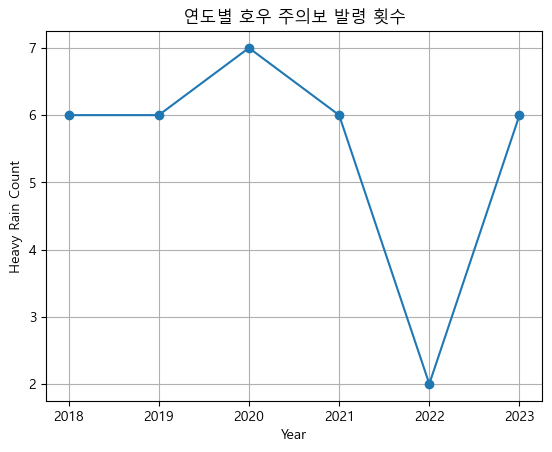

In [14]:
plt.plot(yearly_heavy['year'], yearly_heavy['count'], marker='o')

plt.xlabel('Year')
plt.ylabel('Heavy Rain Count')
plt.title('연도별 호우 주의보 발령 횟수')
plt.grid()

plt.show()

## 연도별 강수량 그래프 그리기

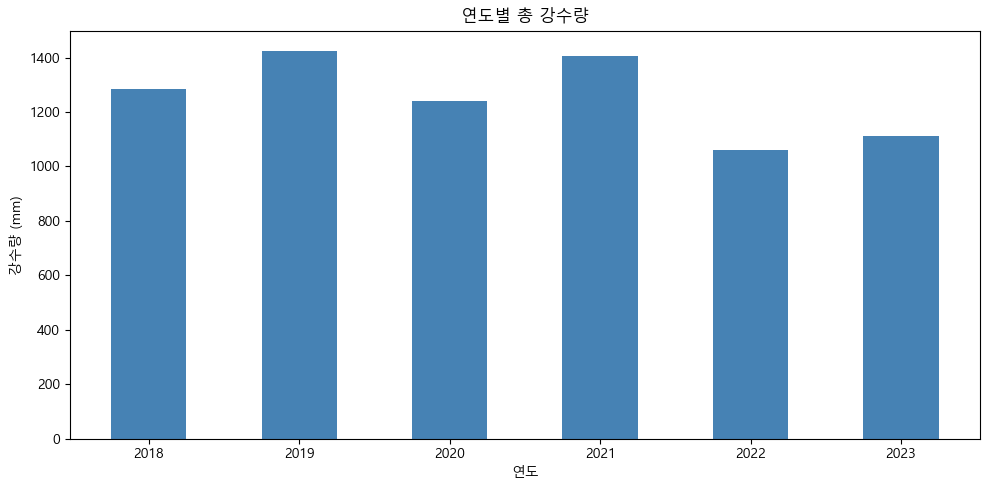

In [15]:
# 연도별 총 강수량 집계
yearly_rain = df2.groupby('year')['hourly_rain'].sum().reset_index()

# 그래프
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly_rain['year'], yearly_rain['hourly_rain'], color='steelblue', width=0.5)

ax.set_title('연도별 총 강수량')
ax.set_xlabel('연도')
ax.set_ylabel('강수량 (mm)')
ax.set_xticks(yearly_rain['year'])

plt.tight_layout()
plt.show()

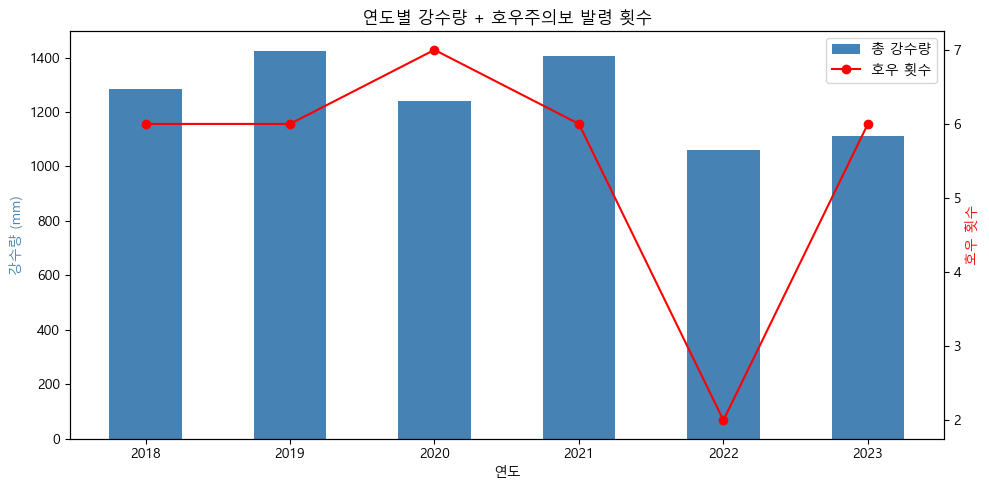

In [16]:
# 1. 연도별 총 강수량
yearly_rain = df2.groupby('year')['hourly_rain'].sum().reset_index()

# 2. 연도별 heavy_rain 개수
yearly_heavy = data_unique1[data_unique1['heavy_rain'] == 1] \
                .groupby('year') \
                .size() \
                .reset_index(name='count')

# 3. 그래프 생성
fig, ax1 = plt.subplots(figsize=(10, 5))

# 👉 막대그래프 (강수량)
ax1.bar(yearly_rain['year'], yearly_rain['hourly_rain'],
        color='steelblue', width=0.5, label='총 강수량')
ax1.set_xlabel('연도')
ax1.set_ylabel('강수량 (mm)', color='steelblue')

# 👉 꺾은선그래프용 y축 추가
ax2 = ax1.twinx()

ax2.plot(yearly_heavy['year'], yearly_heavy['count'],
         color='red', marker='o', label='호우 횟수')
ax2.set_ylabel('호우 횟수', color='red')

# x축 설정
ax1.set_xticks(yearly_rain['year'])

# 제목
plt.title('연도별 강수량 + 호우주의보 발령 횟수')

# 범례 (두 개 합치기)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.tight_layout()
plt.show()

### column 별 의미
- year/month/day/hour : 년/월/일/시
- season : 계절(0=봄/1=여름/2=가을/3=겨울)
- hourly_rain : 시간별 강수량
- rain_3h : 3시간 누적 강수량
- rain_6h : 6시간 누적 강수량
- rain_9h : 9시간 누적 강수량
- rain_12h : 12시간 누적 강수량
- daily_rain : 일별 강수량
- water_level : 형산강 수위
- heavy_risk : 호우주의보 발령 기준 충족 여부(0=충족X/1=충족)  
              -> 3시간 누적 강수량 60mm 이상  
              -> 12시간 누적 강수량 120mm 이상
- heavy_rain : 호우여부(0=호우X/1=호우) -> 호우주의보의 실제 발령 여부

## 'heavy_rain'과 'heavy_risk' 비교

In [17]:
# 전체 일치 개수
match_total = (df2['heavy_rain'] == df2['heavy_risk']).sum
match_total

<bound method Series.sum of 0        True
1        True
2        True
3        True
4        True
         ... 
52579    True
52580    True
52581    True
52582    True
52583    True
Length: 52584, dtype: bool>

In [18]:
# 'heavy_rain'의 값이 1인 행만 필터링
heavy_rain_1 = df2[df2['heavy_rain'] == 1]
heavy_rain_1

,year,month,day,hour,season,hourly_rain,rain_3h,rain_6h,rain_9h,rain_12h,daily_rain,water_level,heavy_risk,heavy_rain
4248,2018,6,27,0,1,0.0,0.0,0.0,0.0,0.0,51.4,1.14,0,1
4249,2018,6,27,1,1,0.0,0.0,0.0,0.0,0.0,51.4,1.14,0,1
4250,2018,6,27,2,1,0.6,0.6,0.6,0.6,0.6,51.4,1.14,0,1
4251,2018,6,27,3,1,0.0,0.6,0.6,0.6,0.6,51.4,1.14,0,1
4252,2018,6,27,4,1,2.2,2.8,2.8,2.8,2.8,51.4,1.14,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50131,2023,9,20,19,2,4.8,7.2,9.5,9.5,9.5,27.2,1.32,0,1
50132,2023,9,20,20,2,2.9,9.3,12.4,12.4,12.4,27.2,1.32,0,1
50133,2023,9,20,21,2,1.9,9.6,13.0,14.3,14.3,27.2,1.32,0,1
50134,2023,9,20,22,2,1.8,6.6,13.8,16.1,16.1,27.2,1.32,0,1


In [19]:
# 'heavy_rain'의 값이 1일 때, 'heavy_risk'와 값이 일치하는 경우
match_heavy_1 = (heavy_rain_1['heavy_rain'] == heavy_rain_1['heavy_risk']).sum()
match_heavy_1

np.int64(12)

In [20]:
# 'heavy_rain'의 값이 1일 때, 'heavy_risk'와 값이 일치하는 경우 출력
heavy_rain_1[heavy_rain_1['heavy_rain'] == heavy_rain_1['heavy_risk']]

,year,month,day,hour,season,hourly_rain,rain_3h,rain_6h,rain_9h,rain_12h,daily_rain,water_level,heavy_risk,heavy_rain
15348,2019,10,2,12,2,12.4,65.0,67.4,68.0,68.6,309.2,1.41,1,1
15349,2019,10,2,13,2,23.9,74.8,90.6,91.5,92.5,309.2,1.41,1,1
15350,2019,10,2,14,2,21.4,57.7,111.5,112.8,113.9,309.2,1.41,1,1
15351,2019,10,2,15,2,26.5,71.8,136.8,139.2,139.8,309.2,1.41,1,1
15352,2019,10,2,16,2,22.9,70.8,145.6,161.4,162.3,309.2,1.41,1,1
15353,2019,10,2,17,2,7.2,56.6,114.3,168.1,169.4,309.2,1.41,1,1
15354,2019,10,2,18,2,4.8,34.9,106.7,171.7,174.1,309.2,1.41,1,1
15355,2019,10,2,19,2,24.1,36.1,106.9,181.7,197.5,309.2,1.41,1,1
15356,2019,10,2,20,2,19.4,48.3,104.9,162.6,216.4,309.2,1.41,1,1
15357,2019,10,2,21,2,8.5,52.0,86.9,158.7,223.7,309.2,1.41,1,1


## 각 연도별/월별 'heavy_rain'의 개수 구하기

In [21]:
#연도별 호우주의보 발령 개수
df2[df2['heavy_rain'] == 1].groupby('year')['heavy_rain'].count()

year
2018    144
2019    144
2020    168
2021    144
2022     48
2023    144
Name: heavy_rain, dtype: int64

In [22]:
# 각 연도의 월별 호우주의보 발령 개수
df2[df2['heavy_rain'] == 1].groupby(['year', 'month'])['heavy_rain'].count().reset_index(name='heavy_rain_count')

,year,month,heavy_rain_count
0,2018,6,24
1,2018,7,24
2,2018,8,48
3,2018,10,48
4,2019,6,24
5,2019,7,48
6,2019,8,24
7,2019,9,24
8,2019,10,24
9,2020,6,24


## 각 연도의 월별 강수량 그래프 출력

In [23]:
# 월별 강수량 계산
monthly_rain = df2.groupby(['year','month'])['hourly_rain'].sum().reset_index()
monthly_rain

,year,month,hourly_rain
0,2018,1,20.0
1,2018,2,30.1
2,2018,3,157.1
3,2018,4,106.5
4,2018,5,71.6
...,...,...,...
67,2023,8,272.5
68,2023,9,142.1
69,2023,10,4.4
70,2023,11,13.1


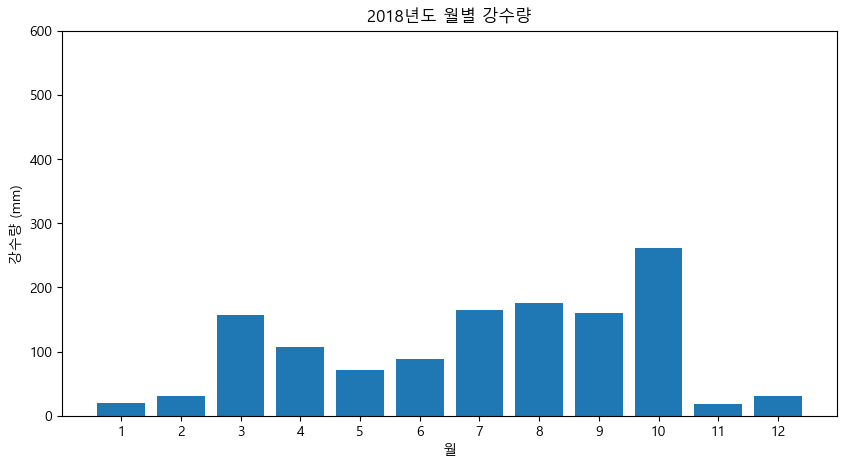

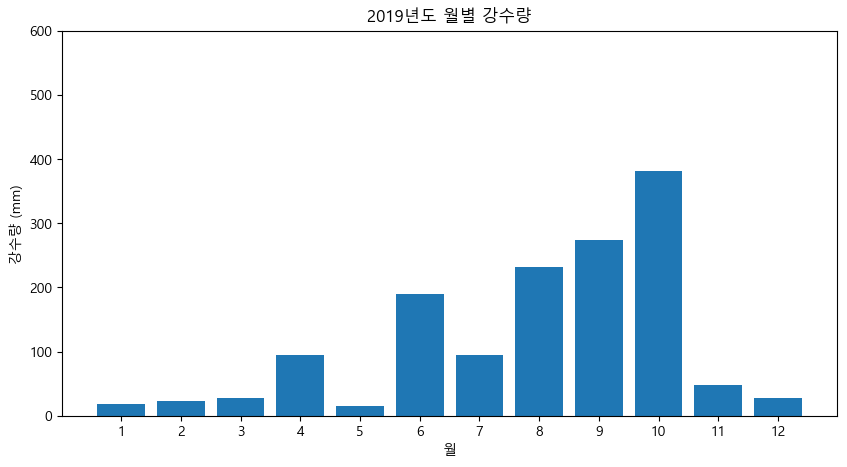

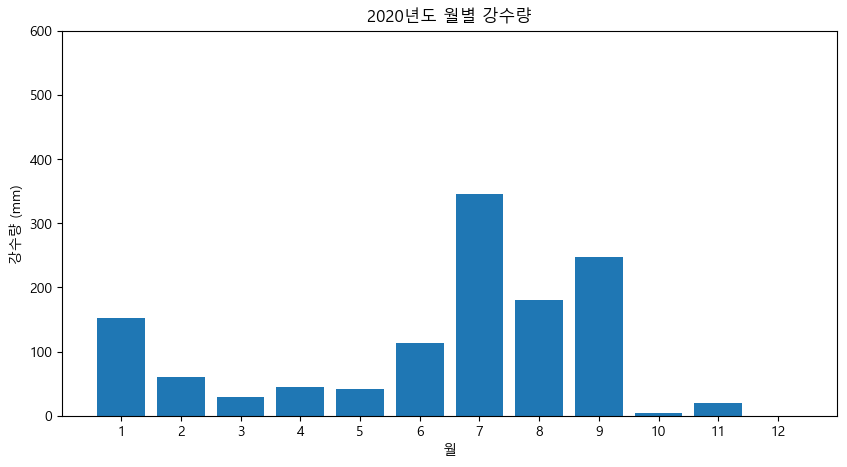

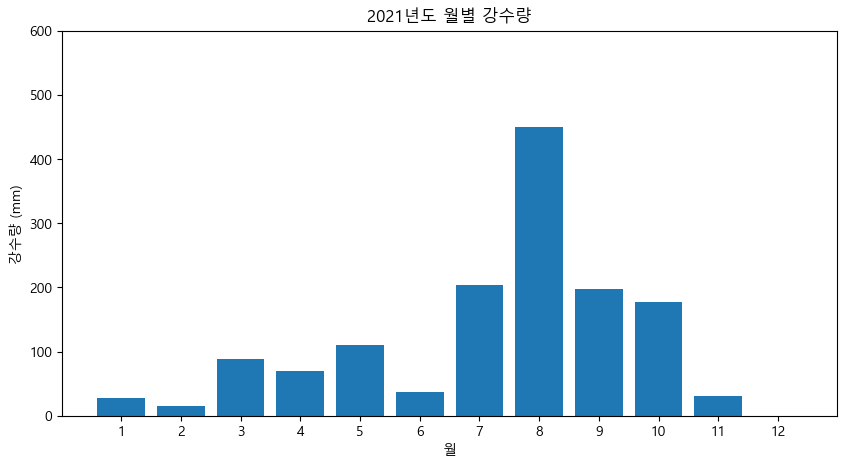

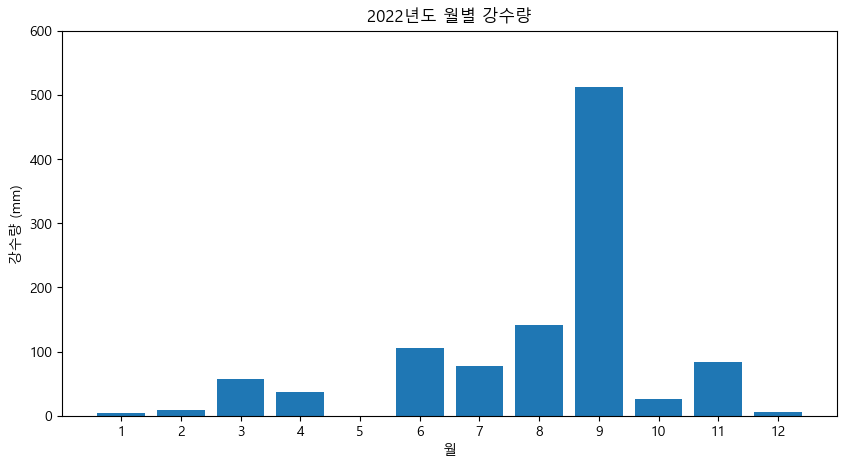

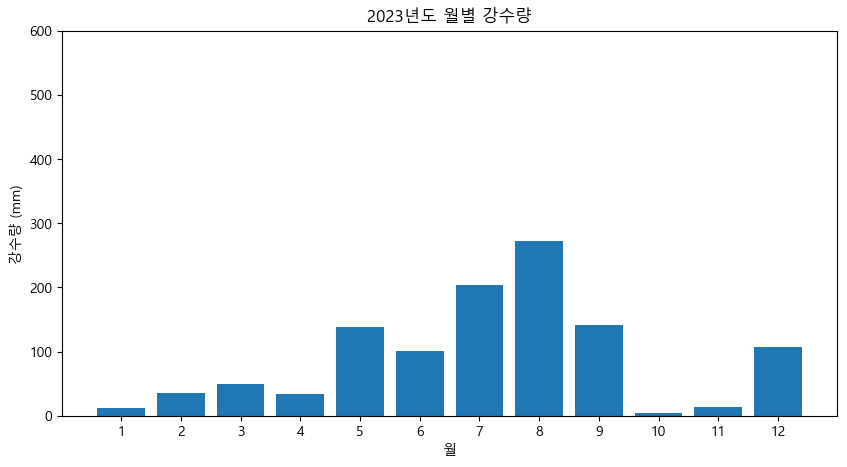

In [24]:
# 각 연도의 월별 강수량 그래프 출력(총 6개, 막대 그래프)
years = monthly_rain['year'].unique()

for y in years:
    data = monthly_rain[monthly_rain['year'] == y]
    
    plt.figure(figsize=(10,5))   # 모든 그래프 동일한 크기
    plt.bar(data['month'], data['hourly_rain'])
    
    plt.title(f'{y}년도 월별 강수량')
    plt.xlabel('월')
    plt.ylabel('강수량 (mm)')
    plt.xticks(range(1,13))
    plt.ylim(0, 600)   # y축 통일
    
    plt.show()

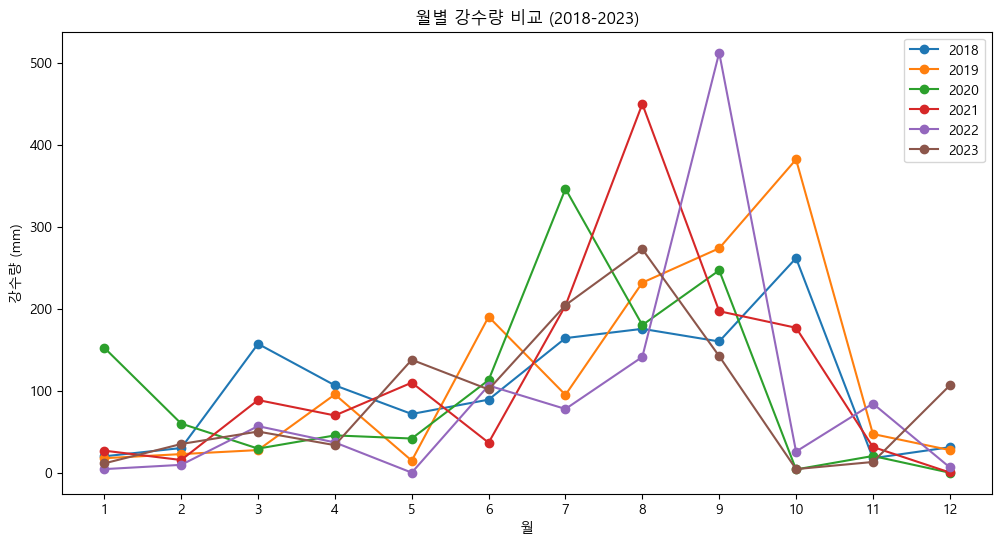

In [25]:
# 6개 연도 비교 그래프
plt.figure(figsize=(12,6))

for y in years:
    data = monthly_rain[monthly_rain['year'] == y]

    plt.plot(data['month'], data['hourly_rain'], marker='o', label=y)

plt.title('월별 강수량 비교 (2018-2023)')
plt.xlabel('월')
plt.ylabel('강수량 (mm)')
plt.xticks(range(1,13))
plt.legend()

plt.show()

## 각 연도별 비가 많이 온 달의 일별 강수량 그래프

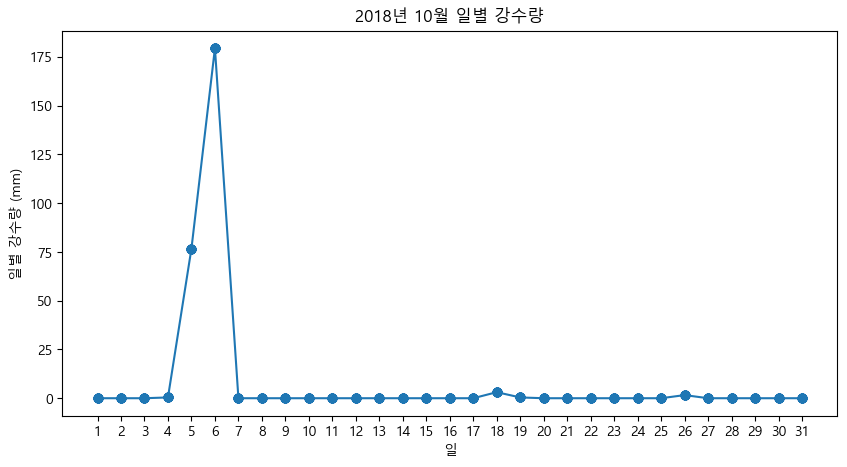

In [26]:
# 2018년 10월
year_target = 2018
month_target = 10

data1 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

plt.figure(figsize=(10,5))

plt.plot(data1['day'], data1['daily_rain'], marker='o')

plt.xlabel('일')
plt.ylabel('일별 강수량 (mm)')
plt.title(f'{year_target}년 {month_target}월 일별 강수량')

plt.xticks(range(1,32))
plt.show()

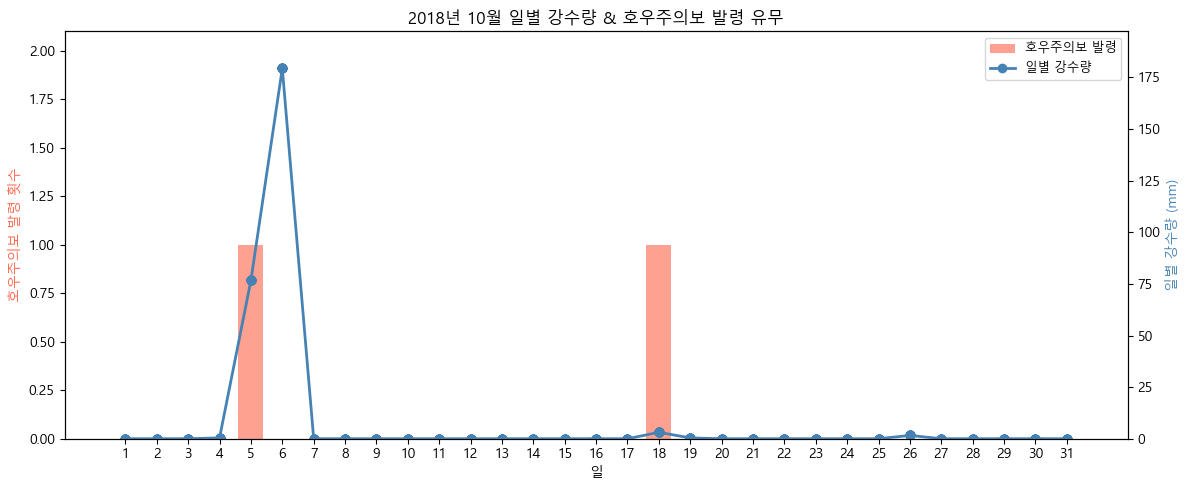

In [27]:
year_target = 2018
month_target = 10

# 꺾은선용 — 일별 강수량
data1 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

# 막대그래프용 — 일별 heavy_rain == 1 개수
daily_heavy = (
    data_unique1[
        (data_unique1['year'] == year_target) &
        (data_unique1['month'] == month_target) &
        (data_unique1['heavy_rain'] == 1)
    ]
    .groupby('day')['heavy_rain']
    .count()
    .reset_index(name='heavy_count')
)

# 모든 날짜 기준으로 맞추기 (없는 날은 0)
all_days = pd.DataFrame({'day': range(1, 32)})
daily_heavy = all_days.merge(daily_heavy, on='day', how='left').fillna(0)

# 그래프
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# 막대그래프 — 호우 발령 횟수
ax1.bar(daily_heavy['day'], daily_heavy['heavy_count'],
        color='tomato', alpha=0.6, label='호우주의보 발령')

# 꺾은선 그래프 — 일별 강수량
ax2.plot(data1['day'], data1['daily_rain'],
         color='steelblue', marker='o', linewidth=2, label='일별 강수량')

# 축 설정
ax1.set_ylim(0, daily_heavy['heavy_count'].max() * 1.1 + 1)
ax2.set_ylim(0, data1['daily_rain'].max() * 1.1)

ax1.set_xlabel('일')
ax1.set_ylabel('호우주의보 발령 횟수', color='tomato')
ax2.set_ylabel('일별 강수량 (mm)', color='steelblue')
ax1.set_xticks(range(1, 32))
ax1.set_title(f'{year_target}년 {month_target}월 일별 강수량 & 호우주의보 발령 유무')

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

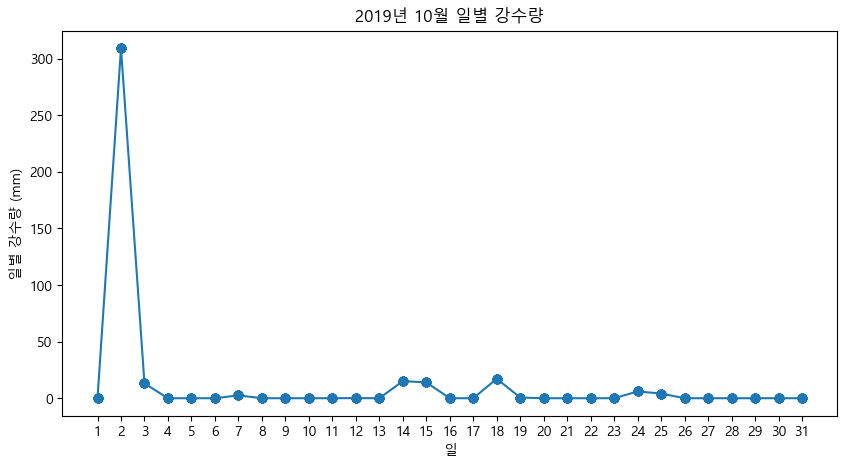

In [28]:
# 2019년 10월
year_target = 2019
month_target = 10

data2 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

plt.figure(figsize=(10,5))

plt.plot(data2['day'], data2['daily_rain'], marker='o')

plt.xlabel('일')
plt.ylabel('일별 강수량 (mm)')
plt.title(f'{year_target}년 {month_target}월 일별 강수량')

plt.xticks(range(1,32))
plt.show()

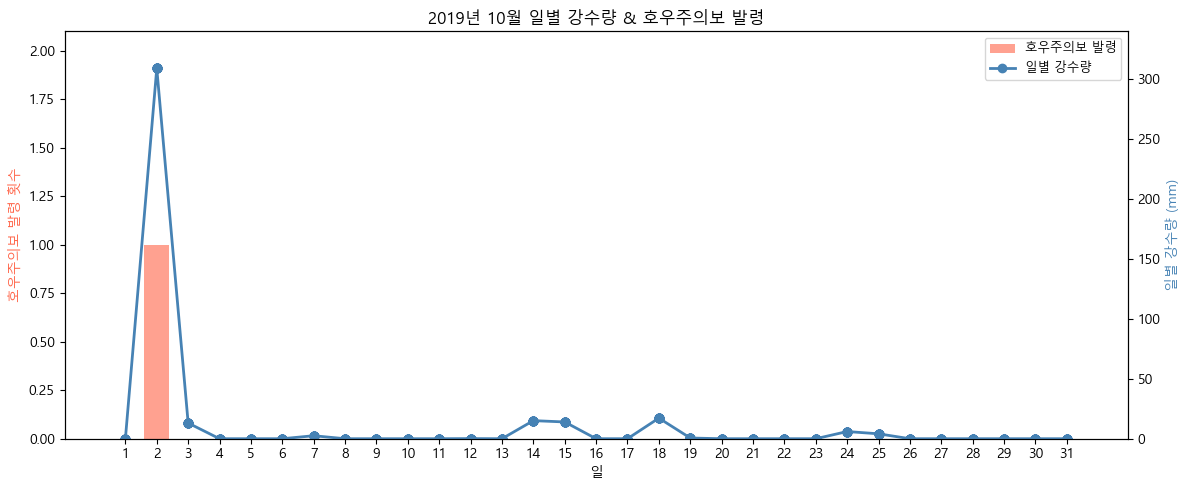

In [29]:
year_target = 2019
month_target = 10

# 꺾은선용 — 일별 강수량
data1 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

# 막대그래프용 — 일별 heavy_rain == 1 개수
daily_heavy = (
    data_unique1[
        (data_unique1['year'] == year_target) &
        (data_unique1['month'] == month_target) &
        (data_unique1['heavy_rain'] == 1)
    ]
    .groupby('day')['heavy_rain']
    .count()
    .reset_index(name='heavy_count')
)

# 모든 날짜 기준으로 맞추기 (없는 날은 0)
all_days = pd.DataFrame({'day': range(1, 32)})
daily_heavy = all_days.merge(daily_heavy, on='day', how='left').fillna(0)

# 그래프
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# 막대그래프 — 호우 발령 횟수
ax1.bar(daily_heavy['day'], daily_heavy['heavy_count'],
        color='tomato', alpha=0.6, label='호우주의보 발령')

# 꺾은선 그래프 — 일별 강수량
ax2.plot(data1['day'], data1['daily_rain'],
         color='steelblue', marker='o', linewidth=2, label='일별 강수량')

# 축 설정
ax1.set_ylim(0, daily_heavy['heavy_count'].max() * 1.1 + 1)
ax2.set_ylim(0, data1['daily_rain'].max() * 1.1)

ax1.set_xlabel('일')
ax1.set_ylabel('호우주의보 발령 횟수', color='tomato')
ax2.set_ylabel('일별 강수량 (mm)', color='steelblue')
ax1.set_xticks(range(1, 32))
ax1.set_title(f'{year_target}년 {month_target}월 일별 강수량 & 호우주의보 발령')

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

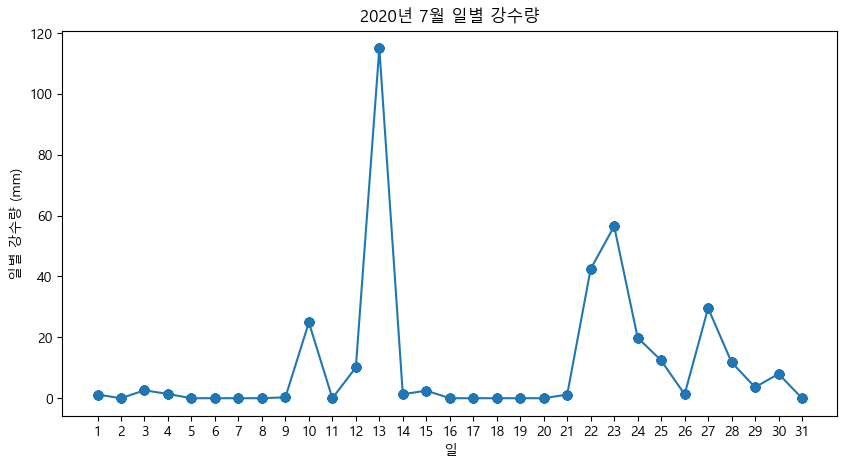

In [30]:
# 2020년 07월
year_target = 2020
month_target = 7

data3 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

plt.figure(figsize=(10,5))

plt.plot(data3['day'], data3['daily_rain'], marker='o')

plt.xlabel('일')
plt.ylabel('일별 강수량 (mm)')
plt.title(f'{year_target}년 {month_target}월 일별 강수량')

plt.xticks(range(1,32))
plt.show()

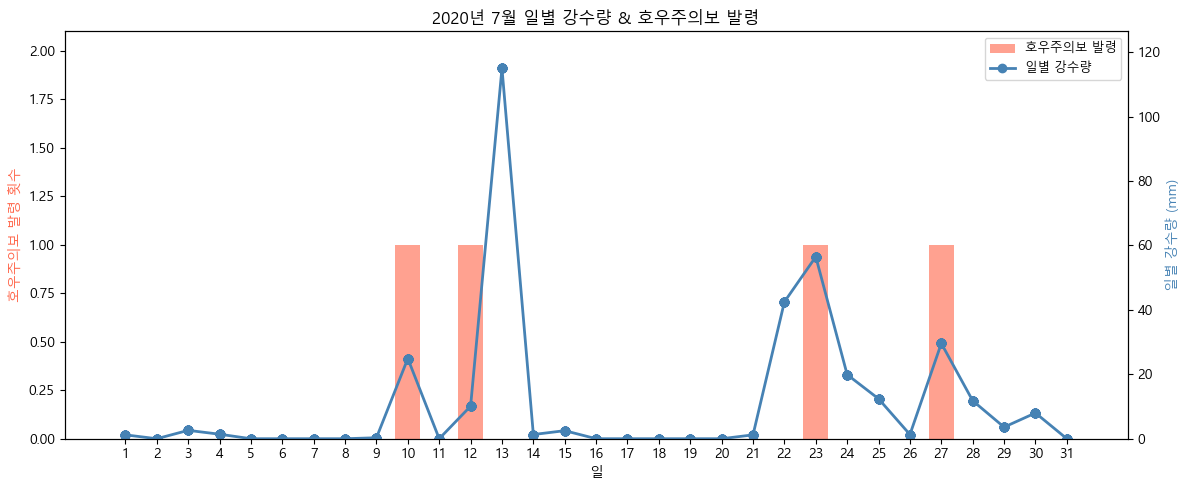

In [31]:
year_target = 2020
month_target = 7

# 꺾은선용 — 일별 강수량
data1 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

# 막대그래프용 — 일별 heavy_rain == 1 개수
daily_heavy = (
    data_unique1[
        (data_unique1['year'] == year_target) &
        (data_unique1['month'] == month_target) &
        (data_unique1['heavy_rain'] == 1)
    ]
    .groupby('day')['heavy_rain']
    .count()
    .reset_index(name='heavy_count')
)

# 모든 날짜 기준으로 맞추기 (없는 날은 0)
all_days = pd.DataFrame({'day': range(1, 32)})
daily_heavy = all_days.merge(daily_heavy, on='day', how='left').fillna(0)

# 그래프
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# 막대그래프 — 호우 발령 횟수
ax1.bar(daily_heavy['day'], daily_heavy['heavy_count'],
        color='tomato', alpha=0.6, label='호우주의보 발령')

# 꺾은선 그래프 — 일별 강수량
ax2.plot(data1['day'], data1['daily_rain'],
         color='steelblue', marker='o', linewidth=2, label='일별 강수량')

# 축 설정
ax1.set_ylim(0, daily_heavy['heavy_count'].max() * 1.1 + 1)
ax2.set_ylim(0, data1['daily_rain'].max() * 1.1)

ax1.set_xlabel('일')
ax1.set_ylabel('호우주의보 발령 횟수', color='tomato')
ax2.set_ylabel('일별 강수량 (mm)', color='steelblue')
ax1.set_xticks(range(1, 32))
ax1.set_title(f'{year_target}년 {month_target}월 일별 강수량 & 호우주의보 발령')

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

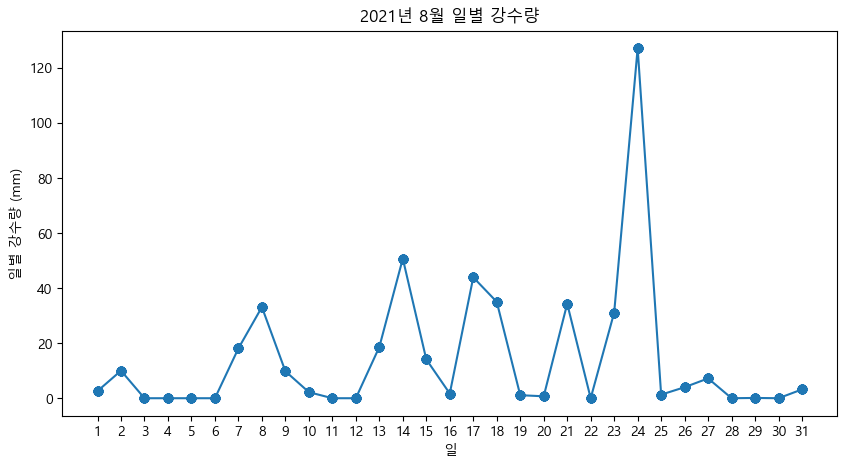

In [32]:
# 2021년 08월
year_target = 2021
month_target = 8

data4 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

plt.figure(figsize=(10,5))

plt.plot(data4['day'], data4['daily_rain'], marker='o')

plt.xlabel('일')
plt.ylabel('일별 강수량 (mm)')
plt.title(f'{year_target}년 {month_target}월 일별 강수량')

plt.xticks(range(1,32))
plt.show()

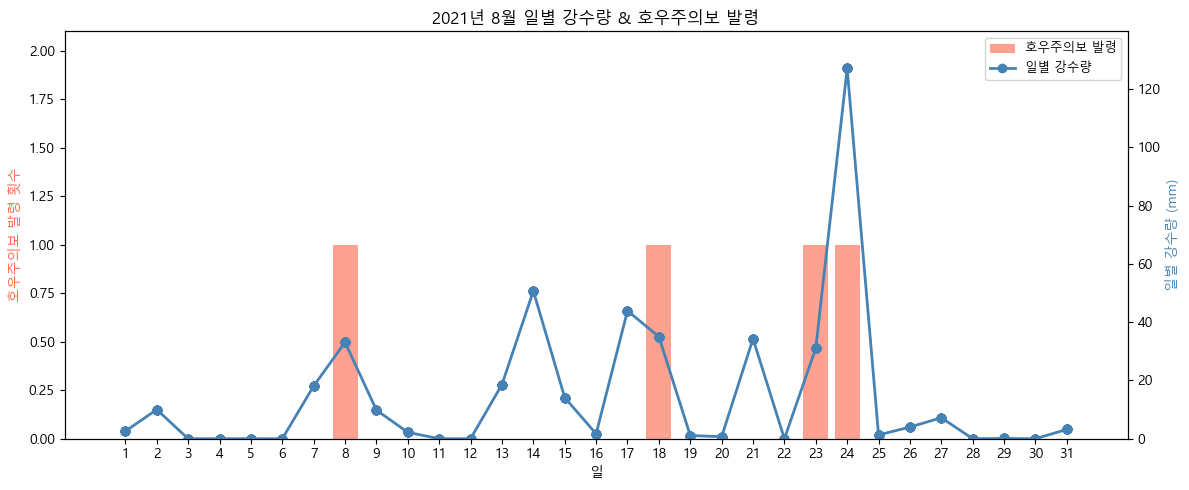

In [33]:
year_target = 2021
month_target = 8

# 꺾은선용 — 일별 강수량
data1 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

# 막대그래프용 — 일별 heavy_rain == 1 개수
daily_heavy = (
    data_unique1[
        (data_unique1['year'] == year_target) &
        (data_unique1['month'] == month_target) &
        (data_unique1['heavy_rain'] == 1)
    ]
    .groupby('day')['heavy_rain']
    .count()
    .reset_index(name='heavy_count')
)

# 모든 날짜 기준으로 맞추기 (없는 날은 0)
all_days = pd.DataFrame({'day': range(1, 32)})
daily_heavy = all_days.merge(daily_heavy, on='day', how='left').fillna(0)

# 그래프
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# 막대그래프 — 호우 발령 횟수
ax1.bar(daily_heavy['day'], daily_heavy['heavy_count'],
        color='tomato', alpha=0.6, label='호우주의보 발령')

# 꺾은선 그래프 — 일별 강수량
ax2.plot(data1['day'], data1['daily_rain'],
         color='steelblue', marker='o', linewidth=2, label='일별 강수량')

# 축 설정
ax1.set_ylim(0, daily_heavy['heavy_count'].max() * 1.1 + 1)
ax2.set_ylim(0, data1['daily_rain'].max() * 1.1)

ax1.set_xlabel('일')
ax1.set_ylabel('호우주의보 발령 횟수', color='tomato')
ax2.set_ylabel('일별 강수량 (mm)', color='steelblue')
ax1.set_xticks(range(1, 32))
ax1.set_title(f'{year_target}년 {month_target}월 일별 강수량 & 호우주의보 발령')

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

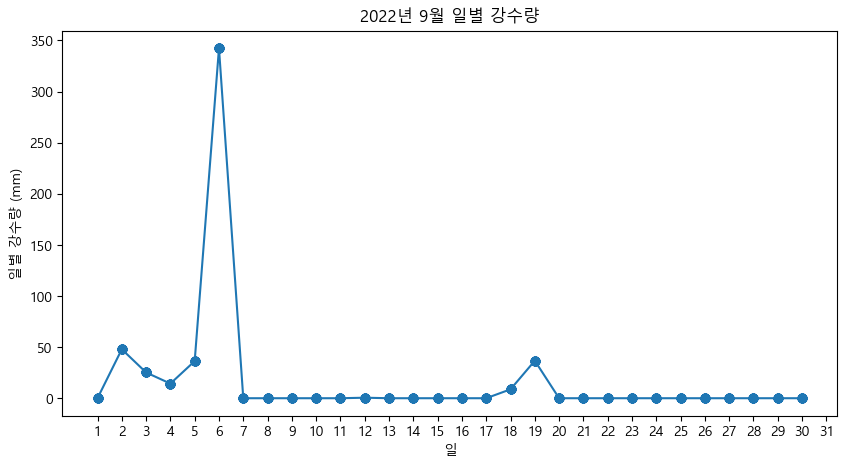

In [34]:
# 2022년 09월
year_target = 2022
month_target = 9

data5 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

plt.figure(figsize=(10,5))

plt.plot(data5['day'], data5['daily_rain'], marker='o')

plt.xlabel('일')
plt.ylabel('일별 강수량 (mm)')
plt.title(f'{year_target}년 {month_target}월 일별 강수량')

plt.xticks(range(1,32))
plt.show()

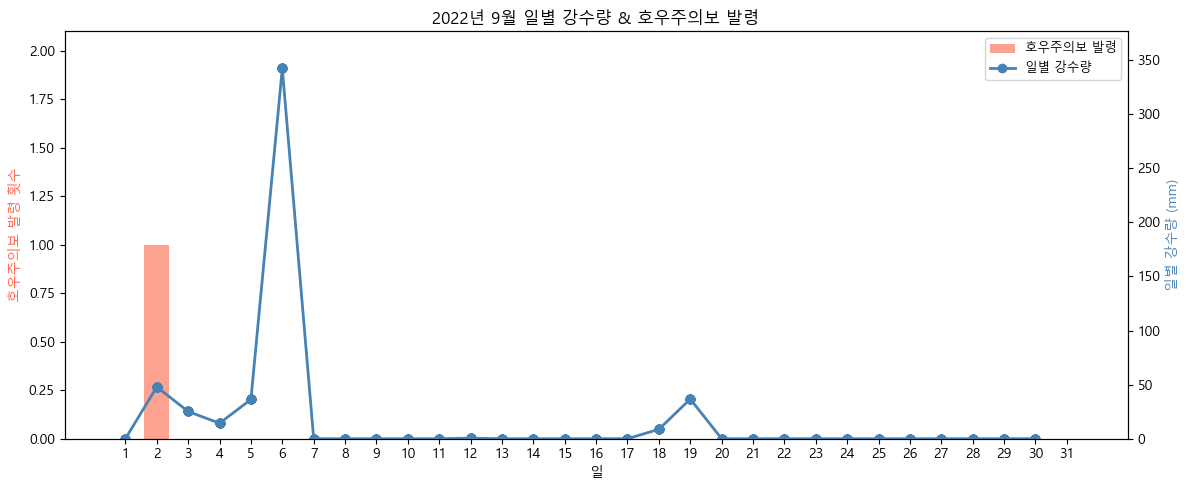

In [35]:
year_target = 2022
month_target = 9

# 꺾은선용 — 일별 강수량
data1 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

# 막대그래프용 — 일별 heavy_rain == 1 개수
daily_heavy = (
    data_unique1[
        (data_unique1['year'] == year_target) &
        (data_unique1['month'] == month_target) &
        (data_unique1['heavy_rain'] == 1)
    ]
    .groupby('day')['heavy_rain']
    .count()
    .reset_index(name='heavy_count')
)

# 모든 날짜 기준으로 맞추기 (없는 날은 0)
all_days = pd.DataFrame({'day': range(1, 32)})
daily_heavy = all_days.merge(daily_heavy, on='day', how='left').fillna(0)

# 그래프
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# 막대그래프 — 호우 발령 횟수
ax1.bar(daily_heavy['day'], daily_heavy['heavy_count'],
        color='tomato', alpha=0.6, label='호우주의보 발령')

# 꺾은선 그래프 — 일별 강수량
ax2.plot(data1['day'], data1['daily_rain'],
         color='steelblue', marker='o', linewidth=2, label='일별 강수량')

# 축 설정
ax1.set_ylim(0, daily_heavy['heavy_count'].max() * 1.1 + 1)
ax2.set_ylim(0, data1['daily_rain'].max() * 1.1)

ax1.set_xlabel('일')
ax1.set_ylabel('호우주의보 발령 횟수', color='tomato')
ax2.set_ylabel('일별 강수량 (mm)', color='steelblue')
ax1.set_xticks(range(1, 32))
ax1.set_title(f'{year_target}년 {month_target}월 일별 강수량 & 호우주의보 발령')

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

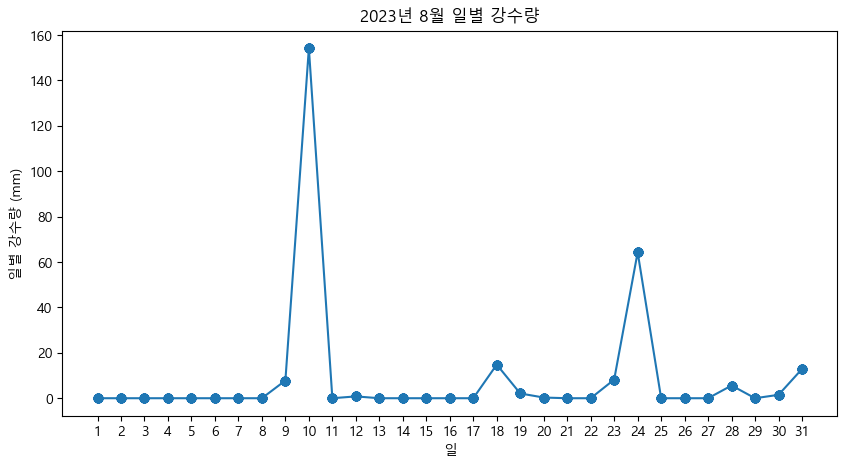

In [36]:
# 2023년 08월
year_target = 2023
month_target = 8

data6 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

plt.figure(figsize=(10,5))

plt.plot(data6['day'], data6['daily_rain'], marker='o')

plt.xlabel('일')
plt.ylabel('일별 강수량 (mm)')
plt.title(f'{year_target}년 {month_target}월 일별 강수량')

plt.xticks(range(1,32))
plt.show()

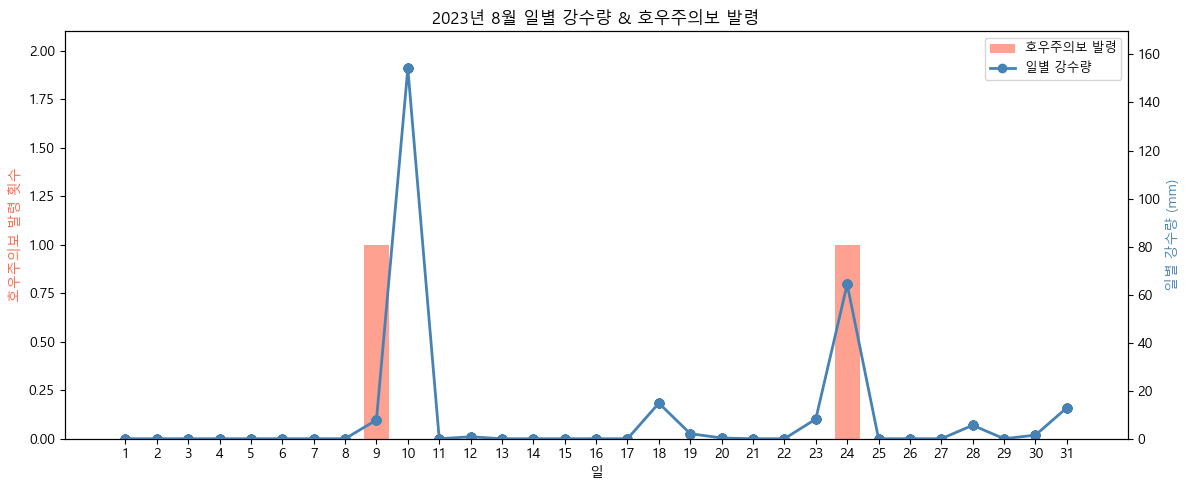

In [37]:
year_target = 2023
month_target = 8

# 꺾은선용 — 일별 강수량
data1 = df2[(df2['year'] == year_target) & (df2['month'] == month_target)]

# 막대그래프용 — 일별 heavy_rain == 1 개수
daily_heavy = (
    data_unique1[
        (data_unique1['year'] == year_target) &
        (data_unique1['month'] == month_target) &
        (data_unique1['heavy_rain'] == 1)
    ]
    .groupby('day')['heavy_rain']
    .count()
    .reset_index(name='heavy_count')
)

# 모든 날짜 기준으로 맞추기 (없는 날은 0)
all_days = pd.DataFrame({'day': range(1, 32)})
daily_heavy = all_days.merge(daily_heavy, on='day', how='left').fillna(0)

# 그래프
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

# 막대그래프 — 호우 발령 횟수
ax1.bar(daily_heavy['day'], daily_heavy['heavy_count'],
        color='tomato', alpha=0.6, label='호우주의보 발령')

# 꺾은선 그래프 — 일별 강수량
ax2.plot(data1['day'], data1['daily_rain'],
         color='steelblue', marker='o', linewidth=2, label='일별 강수량')

# 축 설정
ax1.set_ylim(0, daily_heavy['heavy_count'].max() * 1.1 + 1)
ax2.set_ylim(0, data1['daily_rain'].max() * 1.1)

ax1.set_xlabel('일')
ax1.set_ylabel('호우주의보 발령 횟수', color='tomato')
ax2.set_ylabel('일별 강수량 (mm)', color='steelblue')
ax1.set_xticks(range(1, 32))
ax1.set_title(f'{year_target}년 {month_target}월 일별 강수량 & 호우주의보 발령')

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## 피크 전후 기울기만 뽑기

In [38]:
# 2018년 10월
## 최대값 위치 찾기
peak_idx = data1['daily_rain'].idxmax()
peak_day = data1.loc[peak_idx, 'day']

## 피크 직전 기울기 (상승 구간)
before_peak = data1.loc[peak_idx - 1:peak_idx, :]
slope_up = (before_peak['daily_rain'].iloc[1] - before_peak['daily_rain'].iloc[0])
print(f"피크 상승 기울기: {slope_up:.2f} mm/일")

피크 상승 기울기: 146.40 mm/일


In [39]:
# 2019년 10월
## 최대값 위치 찾기
peak_idx = data2['daily_rain'].idxmax()
peak_day = data2.loc[peak_idx, 'day']

## 피크 직전 기울기 (상승 구간)
before_peak = data2.loc[peak_idx - 1:peak_idx, :]
slope_up = (before_peak['daily_rain'].iloc[1] - before_peak['daily_rain'].iloc[0])
print(f"피크 상승 기울기: {slope_up:.2f} mm/일")

피크 상승 기울기: 309.20 mm/일


In [40]:
# 2020년 07월
## 최대값 위치 찾기
peak_idx = data3['daily_rain'].idxmax()
peak_day = data3.loc[peak_idx, 'day']

## 피크 직전 기울기 (상승 구간)
before_peak = data3.loc[peak_idx - 1:peak_idx, :]
slope_up = (before_peak['daily_rain'].iloc[1] - before_peak['daily_rain'].iloc[0])
print(f"피크 상승 기울기: {slope_up:.2f} mm/일")

피크 상승 기울기: 104.90 mm/일


In [41]:
# 2021년 08월
## 최대값 위치 찾기
peak_idx = data4['daily_rain'].idxmax()
peak_day = data4.loc[peak_idx, 'day']

## 피크 직전 기울기 (상승 구간)
before_peak = data4.loc[peak_idx - 1:peak_idx, :]
slope_up = (before_peak['daily_rain'].iloc[1] - before_peak['daily_rain'].iloc[0])
print(f"피크 상승 기울기: {slope_up:.2f} mm/일")

피크 상승 기울기: 96.00 mm/일


In [42]:
# 2022년 09월
## 최대값 위치 찾기
peak_idx = data5['daily_rain'].idxmax()
peak_day = data5.loc[peak_idx, 'day']

## 피크 직전 기울기 (상승 구간)
before_peak = data5.loc[peak_idx - 1:peak_idx, :]
slope_up = (before_peak['daily_rain'].iloc[1] - before_peak['daily_rain'].iloc[0])
print(f"피크 상승 기울기: {slope_up:.2f} mm/일")

피크 상승 기울기: 306.10 mm/일


In [43]:
# 2023년 08월
## 최대값 위치 찾기
peak_idx = data6['daily_rain'].idxmax()
peak_day = data6.loc[peak_idx, 'day']

## 피크 직전 기울기 (상승 구간)
before_peak = data6.loc[peak_idx - 1:peak_idx, :]
slope_up = (before_peak['daily_rain'].iloc[1] - before_peak['daily_rain'].iloc[0])
print(f"피크 상승 기울기: {slope_up:.2f} mm/일")

피크 상승 기울기: 146.40 mm/일


## 일별 변화량(= 기울기)

In [44]:
# 2018년 10월
target_month = 10
target_year = 2018

data = df2[
    (df2['year'] == target_year) &
    (df2['month'] == target_month)  # month 컬럼 있을 경우
].copy()

# 전날 대비 기울기 (일별 변화량)
data['slope'] = data['daily_rain'].diff()

data = data[['day', 'daily_rain', 'slope']]
data_unique1 = data.drop_duplicates(subset='day')
data_unique1

,day,daily_rain,slope
6552,1,0.0,NaN
6576,2,0.0,0.0
6600,3,0.0,0.0
6624,4,0.4,0.4
6648,5,76.7,76.3
6672,6,179.4,102.7
6696,7,0.0,-179.4
6720,8,0.0,0.0
6744,9,0.0,0.0
6768,10,0.0,0.0


In [45]:
# 2019년 10월
target_month = 10
target_year = 2019

data = df2[
    (df2['year'] == target_year) &
    (df2['month'] == target_month)  # month 컬럼 있을 경우
].copy()

# 전날 대비 기울기 (일별 변화량)
data['slope'] = data['daily_rain'].diff()

data = data[['day', 'daily_rain', 'slope']]
data_unique2 = data.drop_duplicates(subset='day')
data_unique2

,day,daily_rain,slope
15312,1,0.0,NaN
15336,2,309.2,309.2
15360,3,13.1,-296.1
15384,4,0.0,-13.1
15408,5,0.0,0.0
15432,6,0.0,0.0
15456,7,2.5,2.5
15480,8,0.0,-2.5
15504,9,0.0,0.0
15528,10,0.0,0.0


In [46]:
# 2020년 7월
target_month = 7
target_year = 2020

data = df2[
    (df2['year'] == target_year) &
    (df2['month'] == target_month)  # month 컬럼 있을 경우
].copy()

# 전날 대비 기울기 (일별 변화량)
data['slope'] = data['daily_rain'].diff()

data = data[['day', 'daily_rain', 'slope']]
data_unique3 = data.drop_duplicates(subset='day')
data_unique3

,day,daily_rain,slope
21888,1,1.2,NaN
21912,2,0.0,-1.2
21936,3,2.6,2.6
21960,4,1.4,-1.2
21984,5,0.0,-1.4
22008,6,0.0,0.0
22032,7,0.0,0.0
22056,8,0.0,0.0
22080,9,0.3,0.3
22104,10,24.9,24.6


In [47]:
# 2021년 8월
target_month = 8
target_year = 2021

data = df2[
    (df2['year'] == target_year) &
    (df2['month'] == target_month)  # month 컬럼 있을 경우
].copy()

# 전날 대비 기울기 (일별 변화량)
data['slope'] = data['daily_rain'].diff()

data = data[['day', 'daily_rain', 'slope']]
data_unique4 = data.drop_duplicates(subset='day')
data_unique4

,day,daily_rain,slope
31392,1,2.6,NaN
31416,2,10.0,7.4
31440,3,0.0,-10.0
31464,4,0.0,0.0
31488,5,0.0,0.0
31512,6,0.0,0.0
31536,7,18.1,18.1
31560,8,33.1,15.0
31584,9,9.8,-23.3
31608,10,2.2,-7.6


In [48]:
# 2022년 9월
target_month = 9
target_year = 2022

data = df2[
    (df2['year'] == target_year) &
    (df2['month'] == target_month)  # month 컬럼 있을 경우
].copy()

# 전날 대비 기울기 (일별 변화량)
data['slope'] = data['daily_rain'].diff()

data = data[['day', 'daily_rain', 'slope']]
data_unique5 = data.drop_duplicates(subset='day')
data_unique5

,day,daily_rain,slope
40896,1,0.0,NaN
40920,2,47.9,47.9
40944,3,25.2,-22.7
40968,4,14.3,-10.9
40992,5,36.3,22.0
41016,6,342.4,306.1
41040,7,0.0,-342.4
41064,8,0.0,0.0
41088,9,0.0,0.0
41112,10,0.0,0.0


In [49]:
# 2023년 8월
target_month = 8
target_year = 2023

data = df2[
    (df2['year'] == target_year) &
    (df2['month'] == target_month)  # month 컬럼 있을 경우
].copy()

# 전날 대비 기울기 (일별 변화량)
data['slope'] = data['daily_rain'].diff()

data = data[['day', 'daily_rain', 'slope']]
data_unique6 = data.drop_duplicates(subset='day')
data_unique6

,day,daily_rain,slope
48912,1,0.0,NaN
48936,2,0.0,0.0
48960,3,0.0,0.0
48984,4,0.0,0.0
49008,5,0.0,0.0
49032,6,0.0,0.0
49056,7,0.0,0.0
49080,8,0.0,0.0
49104,9,7.8,7.8
49128,10,154.2,146.4
